# Pingviinide analüüs

## Impordid ja seadistused

In [1]:
import pandas as pd
import duckdb

import matplotlib.pyplot as plt
import seaborn as sns

## Andmete laadimine

In [2]:
penguins = sns.load_dataset("penguins")
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [27]:
# Andmetest ülevaate saamiseks. Näit palju on tühje väärtuseid (null_percentage).
# Puuduvate väärtuste puhul: 1) teha mitte midagi, 2) visata välja read, kus on puuduvad väärtused 3) visata välja tulp, kus on puuduvad väärtused, 4) asendada puuduvad väärtused - kas 0-ga, valimi keskmisega
duckdb.sql("""SUMMARIZE penguins""").df()

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,species,VARCHAR,Adelie,Gentoo,3,None,None,None,None,None,344,0.00
1,island,VARCHAR,Biscoe,Torgersen,3,None,None,None,None,None,344,0.00
2,bill_length_mm,DOUBLE,32.1,59.6,186,43.92192982456142,5.459583713926537,39.2625,44.382000000000005,48.51875,344,0.58
3,bill_depth_mm,DOUBLE,13.1,21.5,80,17.151169590643278,1.974793156816781,15.565625,17.318,18.671875,344,0.58
4,flipper_length_mm,DOUBLE,172.0,231.0,51,200.91520467836258,14.061713679356952,190.0,197.06,213.46875,344,0.58
5,body_mass_g,DOUBLE,2700.0,6300.0,77,4201.754385964912,801.9545356980948,3552.34375,4030.5,4769.53125,344,0.58
6,sex,VARCHAR,Female,Male,2,None,None,None,None,None,344,3.20


In [ ]:
# Eemaldame tühjade väärtustega read
penguins_not_null = penguins.dropna()
penguins_not_null

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [5]:
# palju on igas liigis isendeid
duckdb.sql("""
    SELECT
        species, 
        count(*) AS count
    FROM penguins_not_null
    GROUP BY species
""").df()

,species,count
0,Adelie,146
1,Chinstrap,68
2,Gentoo,119


In [6]:
# palju on emaseid ja isaseid
duckdb.sql("""
    SELECT
        sex, 
        count(*) AS count
    FROM penguins_not_null
    GROUP BY sex
""").df()

,sex,count
0,Male,168
1,Female,165


In [7]:
# palju on erinevaid liike ühel saarel
duckdb.sql("""
    SELECT
        island, 
        species,
        count(distinct species) AS count
    FROM penguins_not_null
    GROUP BY island, species
""").df()

,island,species,count
0,Torgersen,Adelie,1
1,Biscoe,Adelie,1
2,Dream,Adelie,1
3,Dream,Chinstrap,1
4,Biscoe,Gentoo,1


In [8]:
# palju on erinevaid liike ühel saarel
duckdb.sql("""
    SELECT
        island,
        count(*) AS count
    FROM penguins_not_null
    GROUP BY island
""").df()

,island,count
0,Dream,123
1,Torgersen,47
2,Biscoe,163


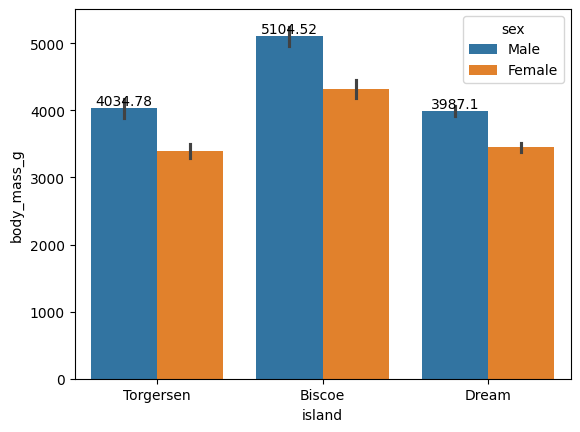

In [9]:
ax = sns.barplot(penguins_not_null, x="island", y="body_mass_g", hue="sex")
# Lisa graafikule 
ax.bar_label(ax.containers[0], fontsize=10);

<Axes: xlabel='body_mass_g', ylabel='species'>

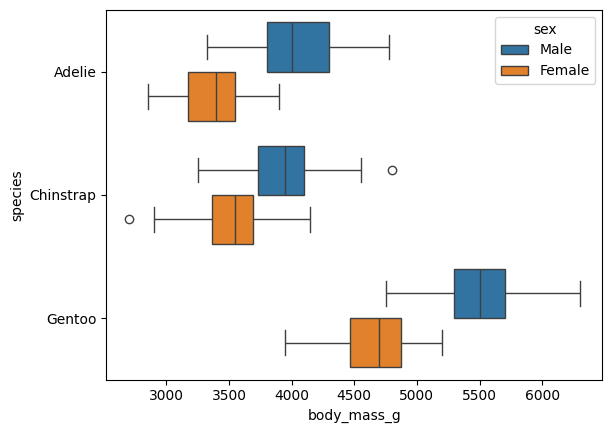

In [10]:
sns.boxplot(penguins_not_null, x="body_mass_g", y="species", hue="sex")

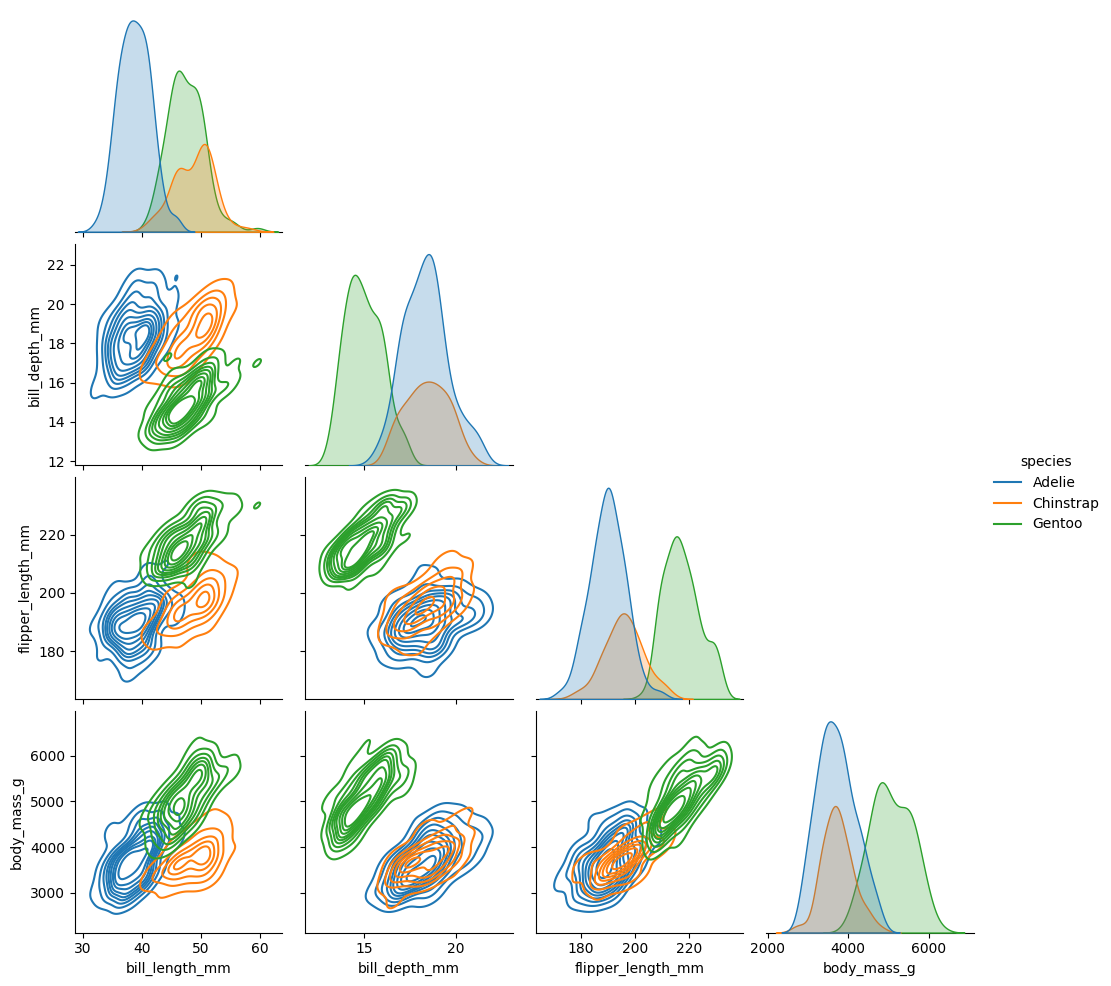

In [11]:
sns.pairplot(penguins, hue="species", kind="kde", corner=True)

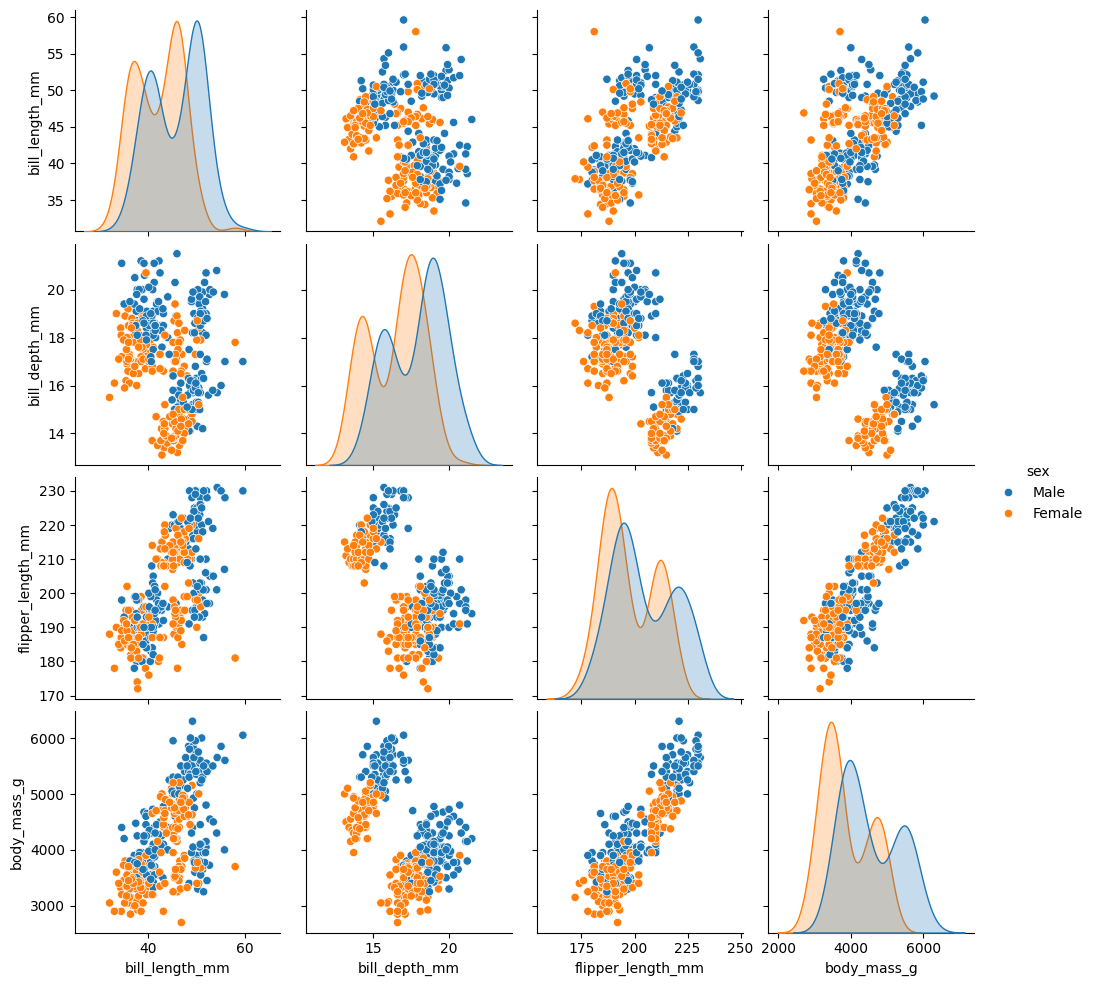

In [29]:
sns.pairplot(penguins, hue="sex")

<Axes: xlabel='flipper_length_mm', ylabel='Density'>

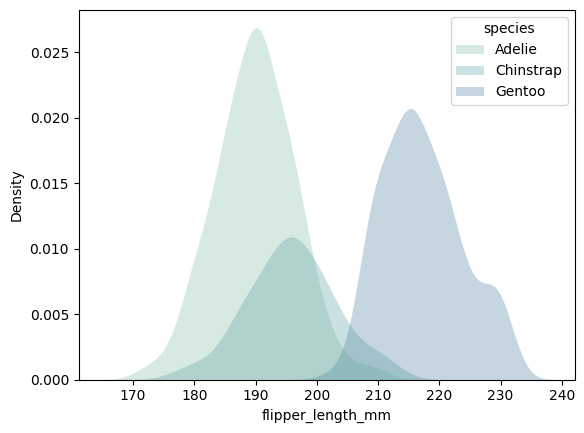

In [12]:
# kdeplot - kaalu jaotus
sns.kdeplot(
    penguins,
    x="flipper_length_mm",
    hue = "species",
    fill=True,
    palette="crest",
    linewidth=0
)

<Axes: xlabel='flipper_length_mm', ylabel='body_mass_g'>

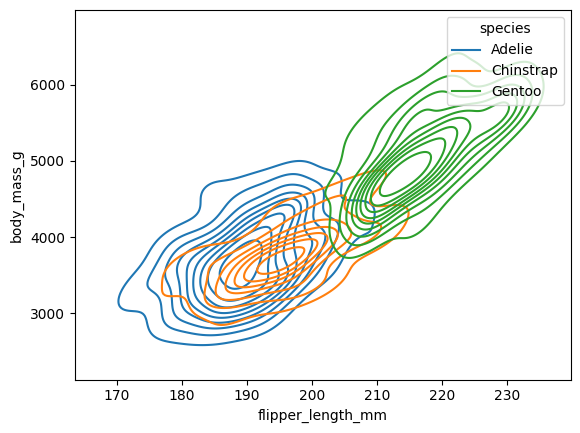

In [13]:
sns.kdeplot(
    penguins,
    x="flipper_length_mm",
    y="body_mass_g",
    hue = "species"
)

<Axes: ylabel='species'>

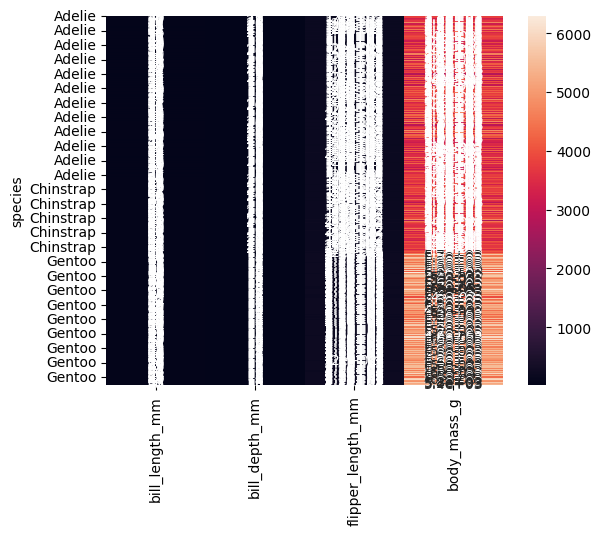

In [14]:
sns.heatmap(
    penguins_not_null[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "species"]].set_index("species"),
    annot=True
)

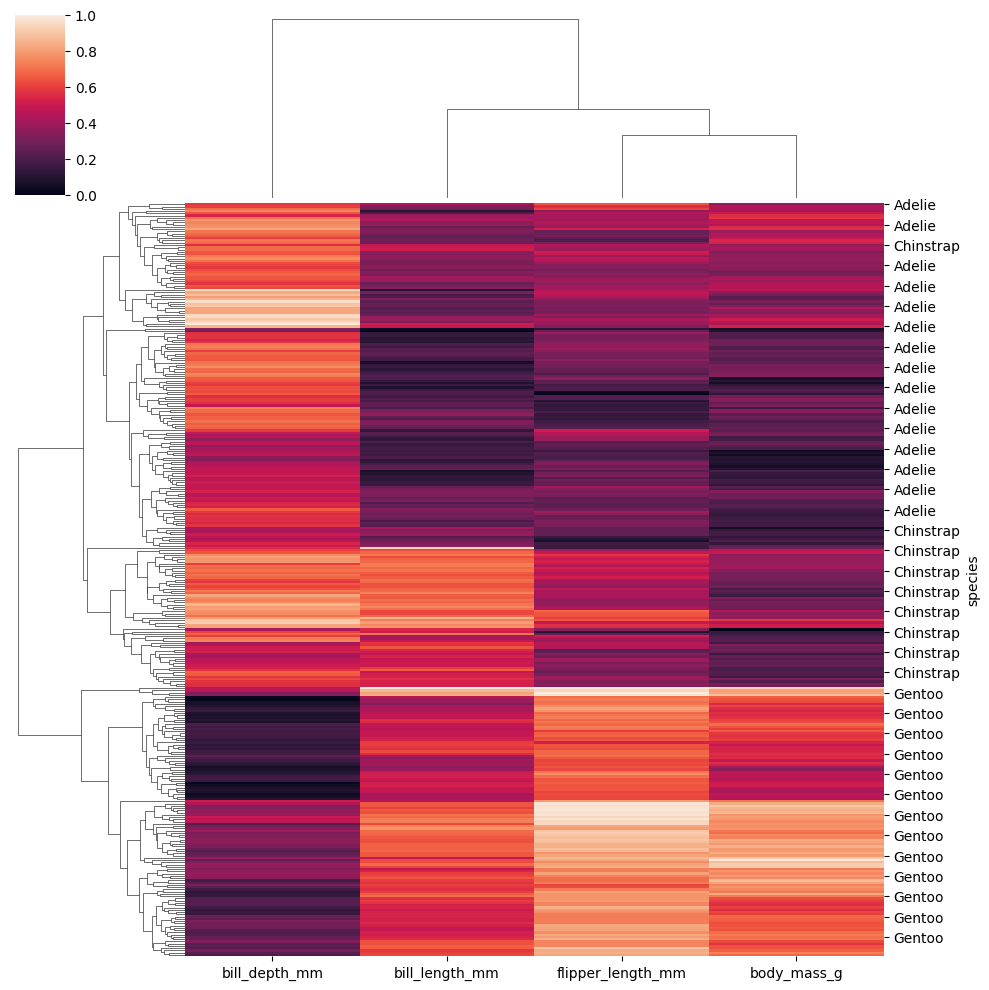

In [15]:
sns.clustermap(
    penguins_not_null[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "species"]].set_index("species")
    ,standard_scale=1
    ,figsize=(10,10)
)

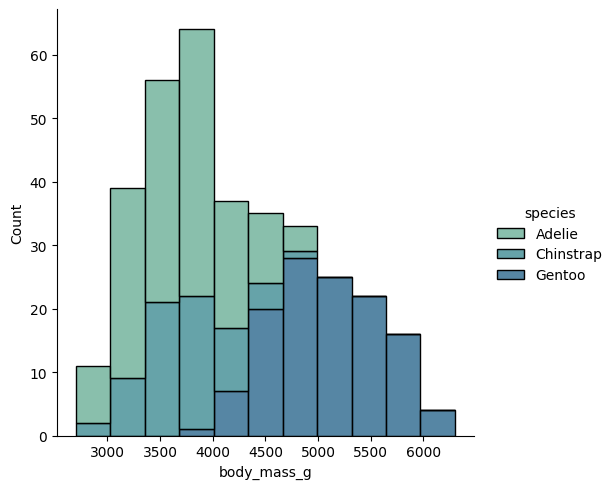

In [16]:
sns.displot(penguins, x="body_mass_g", hue="species", multiple="stack", palette="crest",)

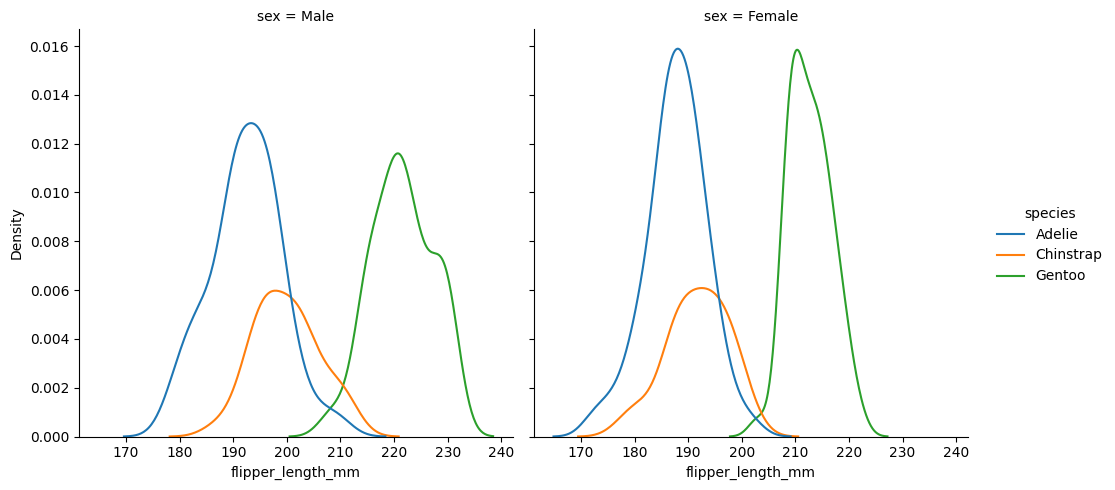

In [17]:
sns.displot(data=penguins, x="flipper_length_mm", hue="species", col="sex", kind="kde")

<Axes: xlabel='body_mass_g', ylabel='Density'>

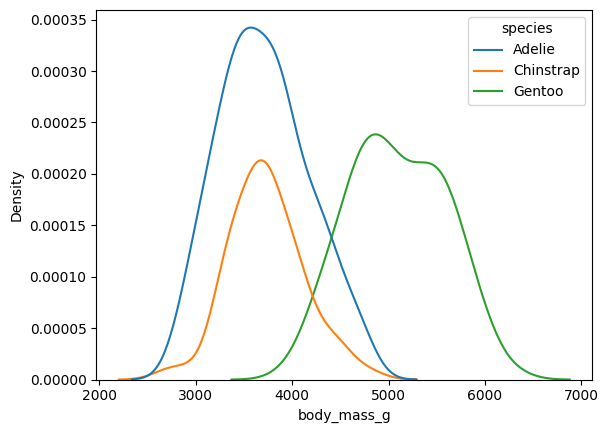

In [18]:
# Kas võib väita, et Adelia ja Chinstrap pingviinide kaaluvahe on statistiliselt oluline?
sns.kdeplot(penguins_not_null, x="body_mass_g", hue="species")

In [ ]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    duckdb.sql("SELECT body_mass_g FROM penguins_not_null WHERE species = 'Adelie'").df()["body_mass_g"],
    duckdb.sql("SELECT body_mass_g FROM penguins_not_null WHERE species = 'Chinstrap'").df()["body_mass_g"],
    alternative='two-sided'
)
float(p)
print(f"{p:.15f}")

# Kuna % suurem kui 50, siis ei ole alust väita, et ... (vähemalt sellise suurusega valimi puhul)

0.547616848670757


<Axes: xlabel='body_mass_g', ylabel='Density'>

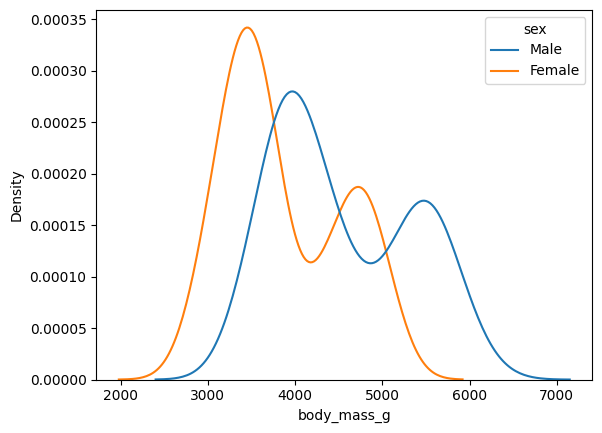

In [19]:
sns.kdeplot(penguins_not_null, x="body_mass_g", hue="sex")

In [20]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    duckdb.sql("SELECT body_mass_g FROM penguins_not_null WHERE sex = 'Male'").df()["body_mass_g"],
    duckdb.sql("SELECT body_mass_g FROM penguins_not_null WHERE sex = 'Female'").df()["body_mass_g"],
    alternative='two-sided'
)
float(p)
print(f"{p:.15f}")

0.000000000000002


# Ennustamine

In [24]:
!pip3 install statsmodels

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 10.0 MB 2.7 MB/s eta 0:00:01
     |████████████████████████████████| 233 kB 2.1 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [ ]:
# Ennustada saab pidevaid tunnuseid (näit töötajate arv, käive) - lineaarne regressioon
# Kategoorilisi, binaarseid tunnuseid (mees/naine) - logistiline regressioon

# Pingviini soo ennustamine massi ja tiivapikkuse järgi
# Oluline vaadata P-väärtuseid

import statsmodels.formula.api as smf

penguins_not_null["sex_binary"] = (penguins_not_null["sex"] == "Male").astype(int)

model = smf.logit("sex_binary ~ body_mass_g + flipper_length_mm", data=penguins_not_null).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.558531
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             sex_binary   No. Observations:                  333
Model:                          Logit   Df Residuals:                      330
Method:                           MLE   Df Model:                            2
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:                  0.1942
Time:                        14:42:30   Log-Likelihood:                -185.99
converged:                       True   LL-Null:                       -230.80
Covariance Type:            nonrobust   LLR p-value:                 3.449e-20
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             7.0868      2.662      2.662      0.008       1.869      12.305
body_mas

/var/folders/rf/7fksn3z54135z8xtsc66dws00000gn/T/ipykernel_44995/4174735055.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  penguins_not_null["sex_binary"] = (penguins_not_null["sex"] == "Male").astype(int)


In [ ]:
new_data = pd.DataFrame({
    "body_mass_g": [4000, 3500, 5000],
    "flipper_length_mm": [200, 185, 210]
})
new_data["pred_prob"] = model.predict(new_data)
new_data["pred_class"] = (new_data["pred_prob"] > 0.5).astype(int)
new_data

# Mida rohkem 1 poole, seda suurem tõenäosus, et tegemist on isasega
# Mida rohkem 0 poole, seda suurem tõenäosus, et tegemist on emasega

,body_mass_g,flipper_length_mm,pred_prob,pred_class
0,4000,200,0.392569,0
1,3500,185,0.394442,0
2,5000,210,0.804225,1
